# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, roc_curve
from sklearn.mixture import GaussianMixture

seed = 31287
plt.rcParams['figure.figsize'] = (8, 8)


In [3]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [4]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [5]:
features = list(data.columns[:-1])
target = 'counterfeit'

data_train, data_test = train_test_split(
    data,
    test_size=0.2,
    shuffle=True,
    stratify=data[target],
    random_state=seed,
)

X_train = data_train[features].to_numpy()
y_train = data_train[target].to_numpy()
X_test = data_test[features].to_numpy()
y_test = data_test[target].to_numpy()


In [6]:
def fit_gmda(X, y, n0, n1, random_state=seed):
    gm0 = GaussianMixture(
        n_components=n0, max_iter=200, tol=0.0001, reg_covar=1e-6,
        random_state=random_state, n_init=2
    )
    gm1 = GaussianMixture(
        n_components=n1, max_iter=200, tol=0.0001, reg_covar=1e-6,
        random_state=random_state + 1, n_init=2
    )
    gm0.fit(X[y == 0])
    gm1.fit(X[y == 1])
    pi1 = y.mean()
    return gm0, gm1, 1.0 - pi1, pi1


def gmda_predict_proba(model, X):
    gm0, gm1, pi0, pi1 = model
    log_p0 = gm0.score_samples(X) + np.log(pi0)
    log_p1 = gm1.score_samples(X) + np.log(pi1)
    max_log = np.maximum(log_p0, log_p1)
    p0 = np.exp(log_p0 - max_log)
    p1 = np.exp(log_p1 - max_log)
    return p1 / (p0 + p1)


def classifier_metrics(name, y_true, proba, threshold=0.5):
    pred = (proba > threshold).astype(int)
    fprs, tprs, thds = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    print(f'{name} confusion matrix, normalized by true class:')
    print(confusion_matrix(y_true, pred, normalize='true'))
    print(f'{name} ROC AUC: {auc:.4f}')
    return {'name': name, 'proba': proba, 'pred': pred, 'fprs': fprs, 'tprs': tprs, 'thds': thds, 'auc': auc}


## Problem 

### C.

Use k-fold cross validation to find the optimal number of gaussian components for each class. As before calculate the confusion matrix, AUC score and plot the ROC curve for the best classifier. Assume that maximal number of components in each class is 12.  

__Hint__ use the `StratifiedKFold` function from scikit-learn library to generate folds. 

 n0  n1  mean_auc  std_auc
 11  10  0.992358 0.003668
 11   5  0.991915 0.000945
 11   6  0.991571 0.003154
 10   9  0.991569 0.003802
 12   8  0.991541 0.002468
 10  10  0.991535 0.003456
 12   5  0.991364 0.001056
 11   9  0.991302 0.003391
 10   6  0.991287 0.001349
  9  12  0.991276 0.004259
Best components: class 0 = 11, class 1 = 10
GMDA 11+10 confusion matrix, normalized by true class:
[[0.95081967 0.04918033]
 [0.10204082 0.89795918]]
GMDA 11+10 ROC AUC: 0.9874


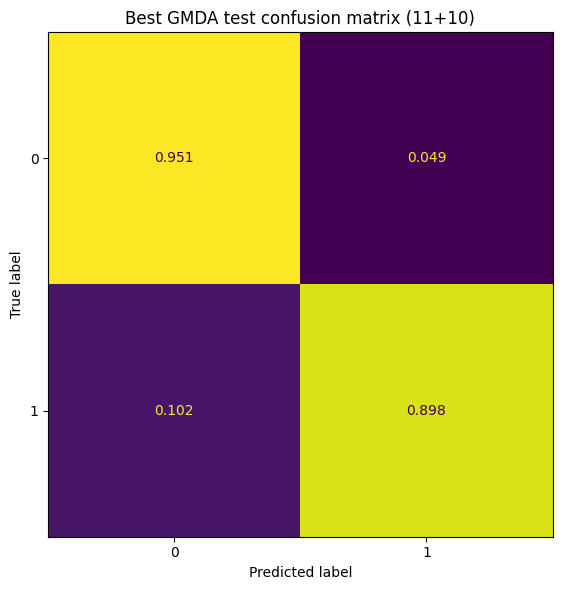

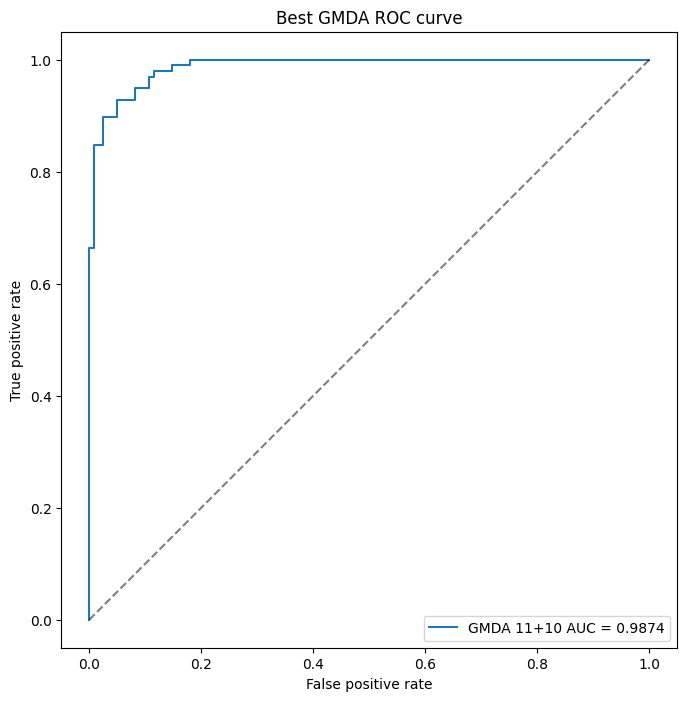

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
cv_results = []

for n0 in range(1, 13):
    for n1 in range(1, 13):
        fold_auc = []
        for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
            model = fit_gmda(
                X_train[train_idx], y_train[train_idx], n0, n1,
                random_state=seed + 1000 * n0 + 100 * n1 + fold,
            )
            valid_proba = gmda_predict_proba(model, X_train[valid_idx])
            fold_auc.append(roc_auc_score(y_train[valid_idx], valid_proba))
        cv_results.append({'n0': n0, 'n1': n1, 'mean_auc': np.mean(fold_auc), 'std_auc': np.std(fold_auc)})

cv_results = pd.DataFrame(cv_results).sort_values('mean_auc', ascending=False).reset_index(drop=True)
best_n0 = int(cv_results.loc[0, 'n0'])
best_n1 = int(cv_results.loc[0, 'n1'])
print(cv_results.head(10).to_string(index=False))
print(f'Best components: class 0 = {best_n0}, class 1 = {best_n1}')

best_gmda = fit_gmda(X_train, y_train, best_n0, best_n1)
best_gmda_test_proba = gmda_predict_proba(best_gmda, X_test)
best_gmda_metrics = classifier_metrics(f'GMDA {best_n0}+{best_n1}', y_test, best_gmda_test_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_gmda_metrics['pred'], normalize='true', values_format='.3f', ax=ax, colorbar=False
)
ax.set_title(f'Best GMDA test confusion matrix ({best_n0}+{best_n1})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(best_gmda_metrics['fprs'], best_gmda_metrics['tprs'], label=f"GMDA {best_n0}+{best_n1} AUC = {best_gmda_metrics['auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Best GMDA ROC curve')
ax.legend()
plt.show()


## D.  

Assume that 1% of all the customers in your store try to pay with a counterfeit 100PLN bill. If you accept the counterfeit bill you loose 100PLN. If you reject a valid bill,  you may loose the purchase, you estimate this loss as 15PLN on average. For each of the three classifiers find the threshold that minimises your losses and calculates the minimum loss for each classifier. Show the optimal classifiers points on the ROC curves.

QDA confusion matrix, normalized by true class:
[[0.81967213 0.18032787]
 [0.28571429 0.71428571]]
QDA ROC AUC: 0.8754
GMDA 2+2 confusion matrix, normalized by true class:
[[0.91803279 0.08196721]
 [0.2755102  0.7244898 ]]
GMDA 2+2 ROC AUC: 0.9404
classifier  threshold      fpr      tpr     loss
       QDA   0.911302 0.000000 0.224490 0.775510
  GMDA 2+2   0.791782 0.000000 0.622449 0.377551
GMDA 11+10   0.725555 0.008197 0.846939 0.274783


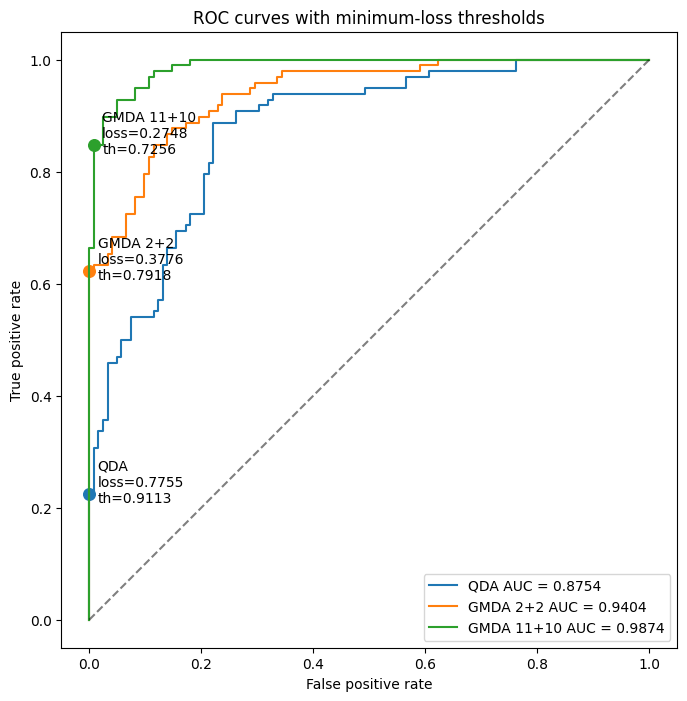

In [8]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train, y_train)
qda_metrics = classifier_metrics('QDA', y_test, qda.predict_proba(X_test)[:, 1])

gmda_2_2 = fit_gmda(X_train, y_train, 2, 2)
gmda_2_2_metrics = classifier_metrics('GMDA 2+2', y_test, gmda_predict_proba(gmda_2_2, X_test))

classifiers = [qda_metrics, gmda_2_2_metrics, best_gmda_metrics]


def optimal_loss_point(metrics, prevalence=0.01, counterfeit_loss=100.0, reject_valid_loss=15.0):
    fprs = metrics['fprs']
    tprs = metrics['tprs']
    thds = metrics['thds']
    losses = prevalence * (1.0 - tprs) * counterfeit_loss + (1.0 - prevalence) * fprs * reject_valid_loss
    idx = int(np.argmin(losses))
    return {
        'classifier': metrics['name'],
        'threshold': thds[idx],
        'fpr': fprs[idx],
        'tpr': tprs[idx],
        'loss': losses[idx],
    }

loss_points = pd.DataFrame([optimal_loss_point(m) for m in classifiers])
print(loss_points.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
for metrics in classifiers:
    point = loss_points[loss_points['classifier'] == metrics['name']].iloc[0]
    ax.plot(metrics['fprs'], metrics['tprs'], label=f"{metrics['name']} AUC = {metrics['auc']:.4f}")
    ax.scatter(point['fpr'], point['tpr'], s=70)
    ax.annotate(
        f"{metrics['name']}\nloss={point['loss']:.4f}\nth={point['threshold']:.4f}",
        (point['fpr'], point['tpr']),
        textcoords='offset points',
        xytext=(6, -6),
    )
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves with minimum-loss thresholds')
ax.legend(loc='lower right')
plt.show()
